Dataset yükleme ve sütunları inceleme

In [1]:
import os
os.chdir("..")

In [2]:
from pathlib import Path

for path in Path(".").rglob("*.csv"):
    print(path)

data\social_media_mental_health.csv
venv\Lib\site-packages\matplotlib\mpl-data\sample_data\data_x_x2_x3.csv
venv\Lib\site-packages\matplotlib\mpl-data\sample_data\msft.csv
venv\Lib\site-packages\matplotlib\mpl-data\sample_data\Stocks.csv
venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-2.csv
venv\Lib\site-packages\numpy\random\tests\data\philox-testset-1.csv
venv\Lib\site-packages\numpy\random\tests\data\philox-testset-2.csv
venv\Lib\site-packages\numpy\random\tests\data\sfc64-testset-1.csv
venv\Lib\site-packages\numpy\random\tests\data\sfc64-testset-2.csv
venv\Lib\site-packages\numpy\_core\tests\data\umath-validation-set-arccos.csv


In [3]:
import pandas as pd

df = pd.read_csv("data/social_media_mental_health.csv")

print(df.columns.tolist())

['User_ID', 'Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours', 'GAD_7_Score', 'GAD_7_Severity', 'PHQ_9_Score', 'PHQ_9_Severity']


Risk Skor ekleyip modelin öğrenmesini artırmaya çalışıyoruz

In [4]:
df["Risk_Score"] = (
    df["Daily_Screen_Time_Hours"] / 12
) + (
    1 - df["Sleep_Duration_Hours"] / 12
)

In [5]:

df["Primary_Platform"].value_counts()




Primary_Platform
TikTok       1185
Instagram    1165
Twitter/X    1147
YouTube      1134
LinkedIn     1132
Snapchat     1124
Facebook     1113
Name: count, dtype: int64

In [6]:
df["Daily_Screen_Time_Hours"].describe()

count    8000.000000
mean        4.277210
std         2.310486
min         0.500000
25%         2.420000
50%         4.270000
75%         6.050000
max        11.310000
Name: Daily_Screen_Time_Hours, dtype: float64

Veriyi anlamak

In [8]:

print(df.head())

print(df.shape)

print(df.info())

print(df.isnull().sum())

      User_ID  Age  Gender      User_Archetype Primary_Platform  \
0  U-b23639d2   18    Male     Hyper-Connected        Twitter/X   
1  U-e7778765   20    Male  Digital Minimalist           TikTok   
2  U-76749892   18  Female  Digital Minimalist         Snapchat   
3  U-dcbbd7f9   18  Female     Hyper-Connected         Snapchat   
4  U-9e1ba278   18    Male     Hyper-Connected         LinkedIn   

   Daily_Screen_Time_Hours Dominant_Content_Type Activity_Type  \
0                     8.50                Gaming        Active   
1                     0.50                Gaming        Active   
2                     0.91                Gaming        Active   
3                     7.43                Gaming        Active   
4                     4.94  Entertainment/Comedy        Active   

   Late_Night_Usage  Social_Comparison_Trigger  Sleep_Duration_Hours  \
0                 0                          0                   3.9   
1                 0                          0          

Veri detayları

In [11]:
print(df["GAD_7_Severity"].value_counts())

print(df["Late_Night_Usage"].value_counts())

print(df["Social_Comparison_Trigger"].value_counts())

print(df["Activity_Type"].value_counts())

GAD_7_Severity
Mild        2891
Minimal     2419
Moderate    2145
Severe       545
Name: count, dtype: int64
Late_Night_Usage
0    4965
1    3035
Name: count, dtype: int64
Social_Comparison_Trigger
0    7175
1     825
Name: count, dtype: int64
Activity_Type
Active     6091
Passive    1909
Name: count, dtype: int64


İlişkilere göz atmak

In [12]:
print(df.groupby("GAD_7_Severity")["Sleep_Duration_Hours"].mean())

print(df.groupby("GAD_7_Severity")["Daily_Screen_Time_Hours"].mean())

GAD_7_Severity
Mild        5.757731
Minimal     6.591484
Moderate    5.158974
Severe      5.081651
Name: Sleep_Duration_Hours, dtype: float64
GAD_7_Severity
Mild        4.359000
Minimal     2.343274
Moderate    5.883324
Severe      6.105872
Name: Daily_Screen_Time_Hours, dtype: float64


Target Dağılımı

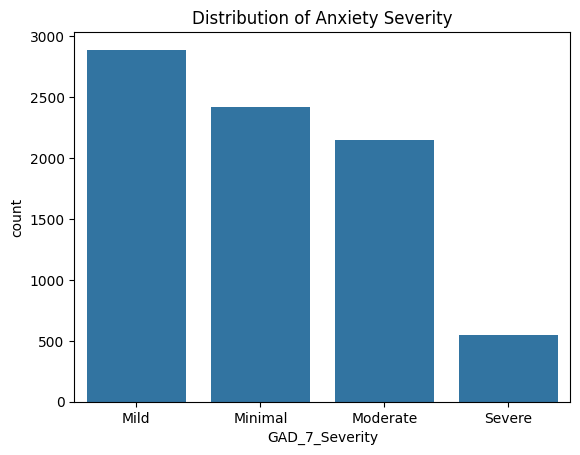

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="GAD_7_Severity")
plt.title("Distribution of Anxiety Severity")
plt.show()

Screen Time vs Anxiety

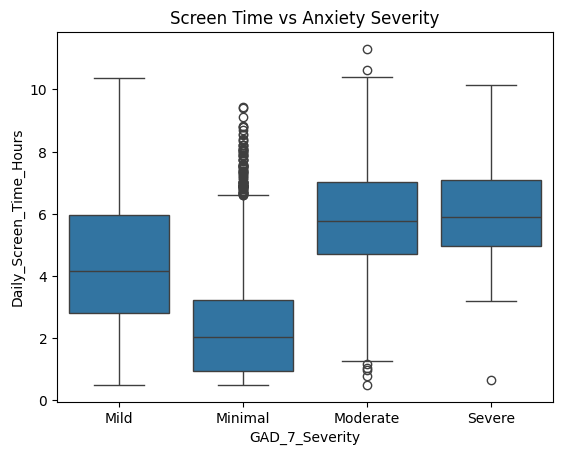

In [14]:
sns.boxplot(
    data=df,
    x="GAD_7_Severity",
    y="Daily_Screen_Time_Hours"
)
plt.title("Screen Time vs Anxiety Severity")
plt.show()

Sleep vs Anxiety

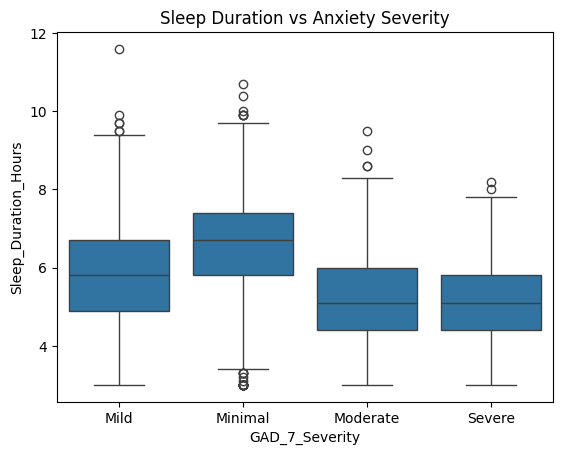

In [15]:
sns.boxplot(
    data=df,
    x="GAD_7_Severity",
    y="Sleep_Duration_Hours"
)
plt.title("Sleep Duration vs Anxiety Severity")
plt.show()

Late Night Usage

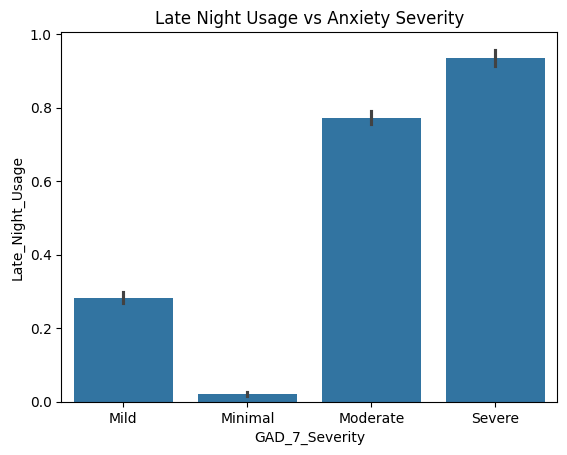

In [16]:
sns.barplot(
    data=df,
    x="GAD_7_Severity",
    y="Late_Night_Usage"
)
plt.title("Late Night Usage vs Anxiety Severity")
plt.show()

Social Comparison

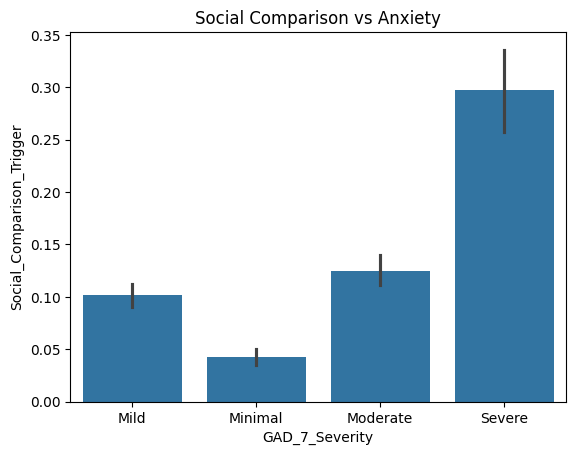

In [17]:
sns.barplot(
    data=df,
    x="GAD_7_Severity",
    y="Social_Comparison_Trigger"
)
plt.title("Social Comparison vs Anxiety")
plt.show()

Korelasyon Matrisi

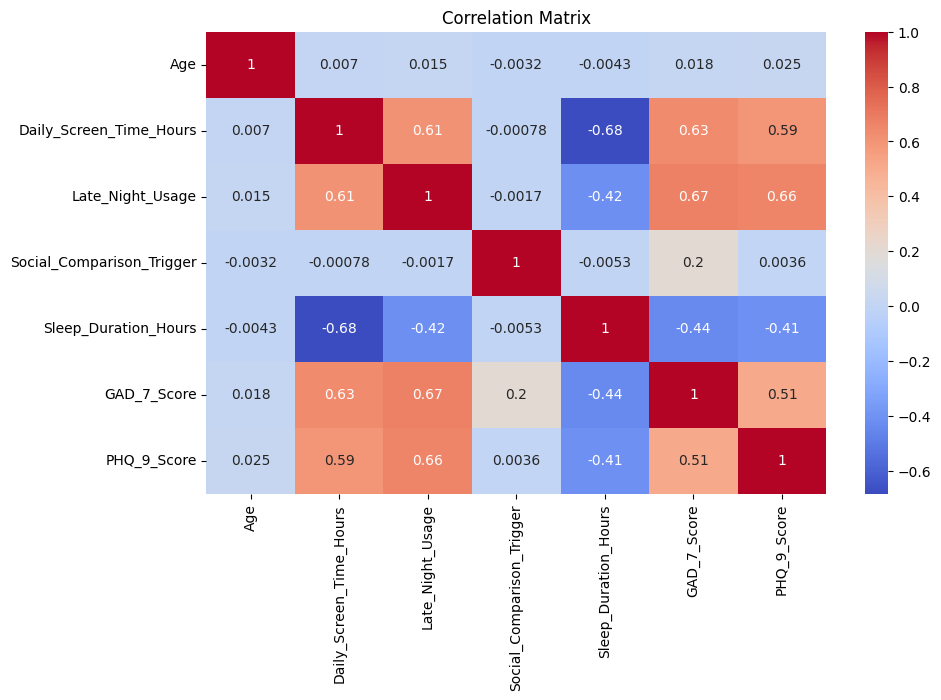

In [18]:
num_df = df.select_dtypes(include=["int64", "float64"])
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Categorical vs Target

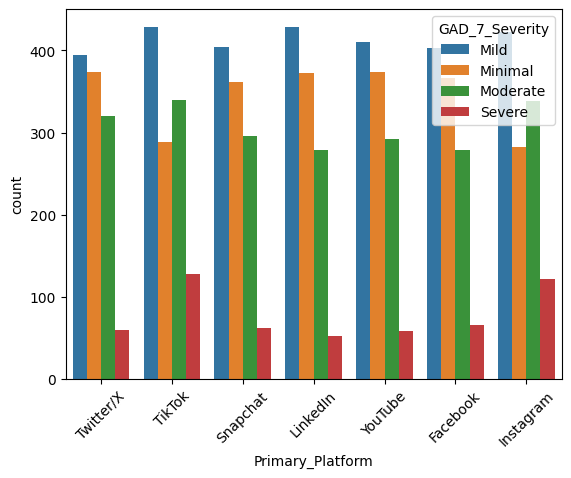

In [19]:
sns.countplot(x="Primary_Platform", hue="GAD_7_Severity", data=df)
plt.xticks(rotation=45)
plt.show()

In [7]:
print(df.head())

      User_ID  Age  Gender      User_Archetype Primary_Platform  \
0  U-b23639d2   18    Male     Hyper-Connected        Twitter/X   
1  U-e7778765   20    Male  Digital Minimalist           TikTok   
2  U-76749892   18  Female  Digital Minimalist         Snapchat   
3  U-dcbbd7f9   18  Female     Hyper-Connected         Snapchat   
4  U-9e1ba278   18    Male     Hyper-Connected         LinkedIn   

   Daily_Screen_Time_Hours Dominant_Content_Type Activity_Type  \
0                     8.50                Gaming        Active   
1                     0.50                Gaming        Active   
2                     0.91                Gaming        Active   
3                     7.43                Gaming        Active   
4                     4.94  Entertainment/Comedy        Active   

   Late_Night_Usage  Social_Comparison_Trigger  Sleep_Duration_Hours  \
0                 0                          0                   3.9   
1                 0                          0          

İhtiyacımız olmayan bazı sütunları eğitim için dropluyoruz

In [6]:
df = df.drop(columns=[
    "User_ID",
    "GAD_7_Score",
    "PHQ_9_Score",
    "PHQ_9_Severity"
])

Input/Output Ayırma
x -> kullanıcı davranışları
y -> hedef gad_severity

In [7]:
X = df.drop("GAD_7_Severity", axis=1)
y = df["GAD_7_Severity"]

Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Preprocessing Pipeline

In [9]:
categorical_features = [
    "Gender",
    "User_Archetype",
    "Primary_Platform",
    "Dominant_Content_Type",
    "Activity_Type"
]

numeric_features = [
    "Age",
    "Daily_Screen_Time_Hours",
    "Sleep_Duration_Hours",
    "Late_Night_Usage",
    "Social_Comparison_Trigger",
    "Risk_Score"
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

Random Forest

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [11]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

Eğitim

In [12]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Mild','Minimal','Moderate','Severe']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Gender','User_Archetype',...,'Social_Comparison_Trigger', 'Sleep_Duration_Hours','Risk_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

Tahmin

In [13]:
y_pred = rf_model.predict(X_test)

Model Değerlendirme

In [14]:
from sklearn.metrics import classification_report, accuracy_score

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.563125
              precision    recall  f1-score   support

        Mild       0.51      0.46      0.49       578
     Minimal       0.67      0.67      0.67       484
    Moderate       0.54      0.69      0.60       429
      Severe       0.36      0.14      0.20       109

    accuracy                           0.56      1600
   macro avg       0.52      0.49      0.49      1600
weighted avg       0.55      0.56      0.55      1600



Xgboost

In [16]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Model kurulumu

In [17]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [18]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

Train

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [20]:
xgb_model.fit(X_train, y_train_enc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Gender','User_Archetype',...,'Social_Comparison_Trigger', 'Sleep_Duration_Hours','Risk_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

Tahmin

In [21]:
y_pred = xgb_model.predict(X_test)

Geri Dönüş

In [22]:
y_pred_labels = le.inverse_transform(y_pred)

Evaluation

In [23]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred))

Accuracy: 0.580625
              precision    recall  f1-score   support

           0       0.54      0.46      0.50       578
           1       0.67      0.70      0.68       484
           2       0.55      0.72      0.63       429
           3       0.38      0.15      0.21       109

    accuracy                           0.58      1600
   macro avg       0.54      0.51      0.50      1600
weighted avg       0.57      0.58      0.57      1600



SHAP kurulum

In [24]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import shap

c:\Users\Zeynep\Desktop\ai_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
model = xgb_model.named_steps["model"]

In [27]:
X_test_transformed = xgb_model.named_steps["preprocessor"].transform(X_test)

In [28]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

Global feature importance

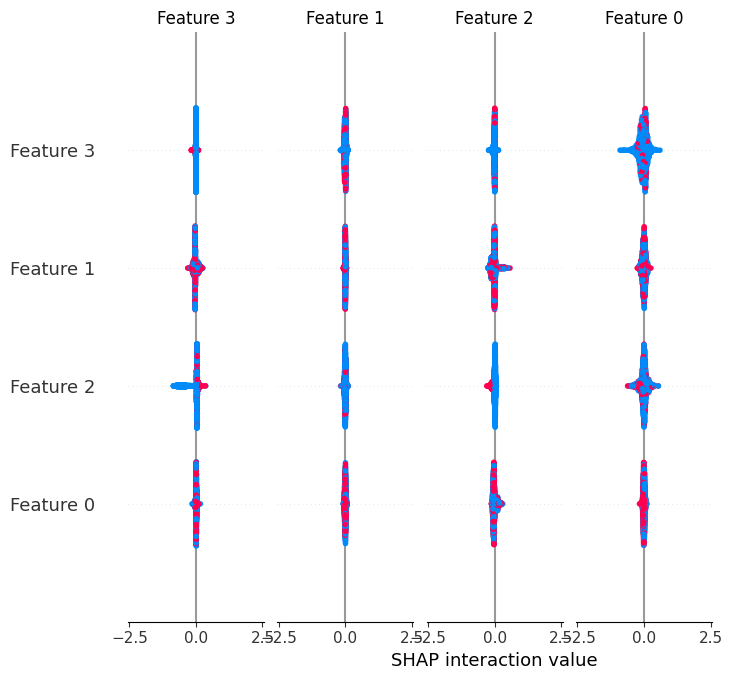

In [30]:
shap.summary_plot(shap_values, X_test_transformed)

feature name problemi

In [31]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

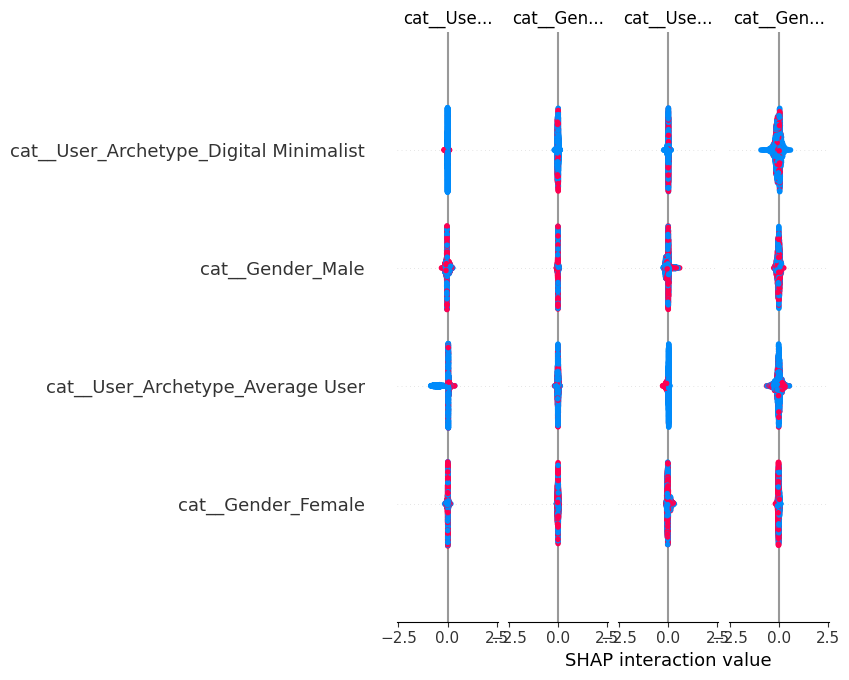

In [32]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

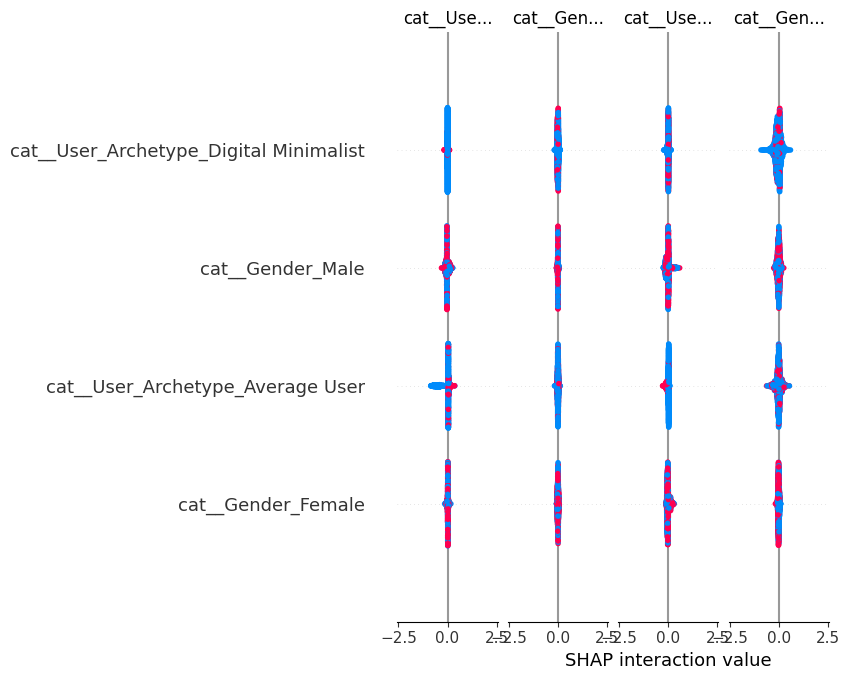

In [33]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

Streamlit

In [34]:
import joblib

joblib.dump(xgb_model, "mental_health_model.pkl")

['mental_health_model.pkl']

In [35]:
print(X.columns)

Index(['Age', 'Gender', 'User_Archetype', 'Primary_Platform',
       'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type',
       'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours',
       'Risk_Score'],
      dtype='str')
